**Example A:**

* We are going to use 2 layers
* optimizer we are going to use SGD
* We are going to use without Normalization

**Example B:**

* We are going to use 3 layers
* optimizer we are going to use Adam
* We are going to use without Normalization

**Example C:**

* We are going to use 2 layers
* optimizer we are going to use Adam
* We are going to use with Normalization and standardization

In [263]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import MinMaxScaler,OneHotEncoder

In [264]:
data=pd.read_csv('/content/insurance_data.csv')
print("Data Loaded Successfully \n")
data.head(10)

Data Loaded Successfully 



,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160


In [265]:
insurance_data_one_hot=pd.get_dummies(data)
insurance_data_one_hot.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,True,False,False


In [266]:
# This command to include all columns as x except for "charges"; which will be y

x=insurance_data_one_hot.drop(["charges"],axis=1)
y=insurance_data_one_hot["charges"]

In [267]:
print("Features : ")
x.head()

Features : 


,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,True,False,False,True,False,False,True
1,18,33.770,1,False,True,True,False,False,True,False
2,28,33.000,3,False,True,True,False,False,True,False
3,33,22.705,0,False,True,True,False,True,False,False
4,32,28.880,0,False,True,True,False,True,False,False


In [268]:
print("Target : ")
y.head()

Target : 


,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520


In [269]:
# first try with a model
#here we try with model: train test split SGD first (train 80%, will test with the remaining untest  20%)

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [270]:
tf.random.set_seed(42)
insurance_model_1=tf.keras.Sequential([
    tf.keras.layers.Dense(200),
    tf.keras.layers.Dense(1)
])

insurance_model_1.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])

history_model1=insurance_model_1.fit(x_train,y_train,epochs=500,verbose=0)

In [278]:
insurance_model_1.evaluate(x_test,y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 8274.9883 - mae: 8274.9883


[8274.98828125, 8274.98828125]

In [279]:
insurance_model_1_loss,insurance_model_1_mae=insurance_model_1.evaluate(x_test,y_test)

print("Loss : ",insurance_model_1_loss)
print("MAE : ",insurance_model_1_mae)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 8274.9883 - mae: 8274.9883
Loss :  8274.98828125
MAE :  8274.98828125


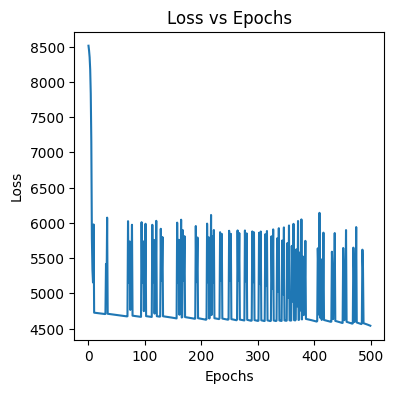

In [280]:
plt.figure(figsize=(4,4))
plt.plot(history_model1.history["loss"])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.show()

In [281]:
# try to change the parameter(s) of train test split - change the density of the neuron model to a more complex with 3 layers and using Adam model instead of SGD and epoch to 350

tf.random.set_seed(42)
insurance_model_2=tf.keras.Sequential([
    tf.keras.layers.Dense(200),
    tf.keras.layers.Dense(20),
    tf.keras.layers.Dense(1)
])

insurance_model_2.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["mae"])

history_model2=insurance_model_2.fit(x_train,y_train,epochs=500,verbose=0)

In [282]:
insurance_model_2.evaluate(x_test,y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 7883.0366 - mae: 7883.0366


[7883.03662109375, 7883.03662109375]

In [283]:
insurance_model_2_loss,insurance_model_2_mae=insurance_model_2.evaluate(x_test,y_test)

print("Loss : ",insurance_model_2_loss)
print("MAE : ",insurance_model_2_mae)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 7883.0366 - mae: 7883.0366
Loss :  7883.03662109375
MAE :  7883.03662109375


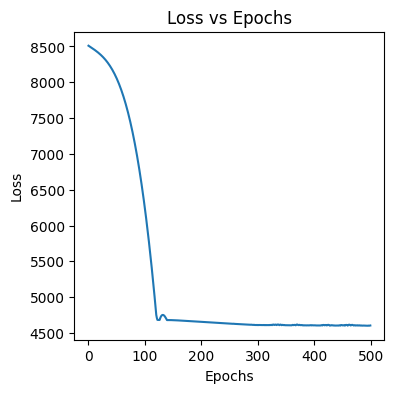

In [284]:
plt.figure(figsize=(4,4))
plt.plot(history_model2.history["loss"])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.show()


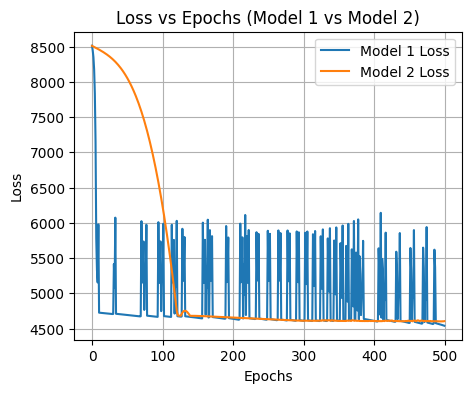

In [285]:
plt.figure(figsize=(5,4))
plt.plot(history_model1.history["loss"], label="Model 1 Loss")
plt.plot(history_model2.history["loss"], label="Model 2 Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs (Model 1 vs Model 2)")
plt.legend()  # show the labels
plt.grid(True)
plt.show()

In [286]:
# Using Adam but with normalized data

data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [287]:
# Normalization

ct=make_column_transformer(
    (MinMaxScaler(),["age","bmi","children"]),
    (OneHotEncoder(handle_unknown="ignore"),["sex","smoker","region"])
)

In [288]:
x=data.drop("charges",axis=1)
y=data["charges"]

In [289]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [290]:
ct.fit(x_train)

ColumnTransformer(transformers=[('minmaxscaler', MinMaxScaler(),
                                 ['age', 'bmi', 'children']),
                                ('onehotencoder',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['sex', 'smoker', 'region'])])

In [291]:
x_train_normalized=ct.transform(x_train)
x_test_normalized=ct.transform(x_test)

In [292]:
print("x_train original :",x_train)
print("\nshape of x_train original ",x_train.shape)
print("\n\nx_train normalized :",x_train_normalized)
print("\nshape of x_train normalized ",x_train_normalized.shape)


x_train original :    age     sex     bmi  children smoker     region
5   31  female  25.740         0     no  southeast
2   28    male  33.000         3     no  southeast
4   32    male  28.880         0     no  northwest
3   33    male  22.705         0     no  northwest

shape of x_train original  (4, 6)


x_train normalized : [[0.6        0.2948033  0.         1.         0.         1.
  0.         1.        ]
 [0.         1.         1.         0.         1.         1.
  0.         1.        ]
 [0.8        0.59980573 0.         0.         1.         1.
  1.         0.        ]
 [1.         0.         0.         0.         1.         1.
  1.         0.        ]]

shape of x_train normalized  (4, 8)


In [295]:
tf.random.set_seed(42)
insurance_model_3=tf.keras.Sequential([
    tf.keras.layers.Dense(200),
    tf.keras.layers.Dense(20),
    tf.keras.layers.Dense(1)
])

insurance_model_3.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["mae"])

history_model3=insurance_model_3.fit(x_train_normalized,y_train,epochs=500,verbose=0)

In [296]:
insurance_model_3.evaluate(x_test_normalized,y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - loss: 8597.8691 - mae: 8597.8691


[8597.869140625, 8597.869140625]

In [297]:
insurance_model_3_loss,insurance_model_3_mae=insurance_model_3.evaluate(x_test_normalized,y_test)

print("Loss : ",insurance_model_2_loss)
print("MAE : ",insurance_model_2_mae)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 8597.8691 - mae: 8597.8691
Loss :  7883.03662109375
MAE :  7883.03662109375


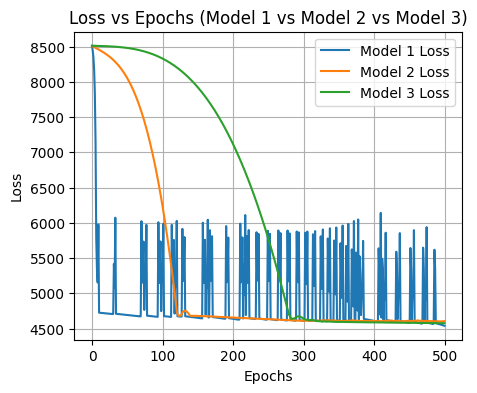

In [298]:
plt.figure(figsize=(5,4))
plt.plot(history_model1.history["loss"], label="Model 1 Loss")
plt.plot(history_model2.history["loss"], label="Model 2 Loss")
plt.plot(history_model3.history["loss"], label="Model 3 Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs (Model 1 vs Model 2 vs Model 3)")
plt.legend()  # show the labels
plt.grid(True)
plt.show()